#Efficient SAM Example

This script provides example for how to get visualization result from EfficientSAM using weight file, part of the code is borrow from MobileSAM project, many thanks!

##Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision.transforms import ToTensor
from PIL import Image
import io

#Box and Point prompt

In [2]:
def run_ours_box_or_points(img_path, pts_sampled, pts_labels, model):
    image_np = np.array(Image.open(img_path))
    img_tensor = ToTensor()(image_np)
    pts_sampled = torch.reshape(torch.tensor(pts_sampled), [1, 1, -1, 2])
    pts_labels = torch.reshape(torch.tensor(pts_labels), [1, 1, -1])
    predicted_logits, predicted_iou = model(
        img_tensor[None, ...],
        pts_sampled,
        pts_labels,
    )

    sorted_ids = torch.argsort(predicted_iou, dim=-1, descending=True)
    predicted_iou = torch.take_along_dim(predicted_iou, sorted_ids, dim=2)
    predicted_logits = torch.take_along_dim(
        predicted_logits, sorted_ids[..., None, None], dim=2
    )

    return torch.ge(predicted_logits[0, 0, 0, :, :], 0).cpu().detach().numpy()

#Visualization Related

In [3]:
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30 / 255, 144 / 255, 255 / 255, 0.8])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels == 1]
    neg_points = coords[labels == 0]
    ax.scatter(
        pos_points[:, 0],
        pos_points[:, 1],
        color="green",
        marker="*",
        s=marker_size,
        edgecolor="white",
        linewidth=1.25,
    )
    ax.scatter(
        neg_points[:, 0],
        neg_points[:, 1],
        color="red",
        marker="*",
        s=marker_size,
        edgecolor="white",
        linewidth=1.25,
    )


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(
        plt.Rectangle((x0, y0), w, h, edgecolor="yellow", facecolor=(0, 0, 0, 0), lw=5)
    )

def show_anns_ours(mask, ax):
    ax.set_autoscale_on(False)
    img = np.ones((mask.shape[0], mask.shape[1], 4))
    img[:, :, 3] = 0
    color_mask = [0, 1, 0, 0.7]
    img[np.logical_not(mask)] = color_mask
    ax.imshow(img)


#Create the model and load the weights from the checkpoint.

In [6]:
!git clone https://github.com/yformer/EfficientSAM.git
import os
os.chdir("EfficientSAM")

Cloning into 'EfficientSAM'...
remote: Enumerating objects: 444, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 444 (delta 86), reused 65 (delta 57), pack-reused 339 (from 1)
Receiving objects: 100% (444/444), 263.09 MiB | 33.78 MiB/s, done.
Resolving deltas: 100% (256/256), done.
Updating files: 100% (39/39), done.


In [19]:
import sys
import os
import zipfile

# Save current working directory
original_cwd = os.getcwd()

# Go to the parent directory to clone SqueezeSAM
os.chdir(".." if os.path.basename(original_cwd) == "EfficientSAM" else original_cwd)

# Clone SqueezeSAM if it doesn't exist
squeeze_sam_repo_url = "https://github.com/Li-Qingzhou/SqueezeSAM.git"
squeeze_sam_dir = "SqueezeSAM"
if not os.path.exists(squeeze_sam_dir):
    print(f"Cloning {squeeze_sam_repo_url}...")
    !git clone {squeeze_sam_repo_url}
    print("SqueezeSAM cloned.")
else:
    print("SqueezeSAM repository already exists.")

# Add SqueezeSAM to sys.path so its modules can be imported
if os.path.abspath(squeeze_sam_dir) not in sys.path:
    sys.path.append(os.path.abspath(squeeze_sam_dir))
    print(f"Added {os.path.abspath(squeeze_sam_dir)} to sys.path")

# Change back to the original directory (EfficientSAM) if it was changed
if os.path.basename(original_cwd) == "EfficientSAM" and os.getcwd() != original_cwd:
    os.chdir(original_cwd)
    print(f"Changed back to original directory: {os.getcwd()}")

# Now, perform the imports
from efficient_sam.build_efficient_sam import build_efficient_sam_vitt, build_efficient_sam_vits
#from squeeze_sam.build_squeeze_sam import build_squeeze_sam#
import zipfile

efficient_sam_vitt_model = build_efficient_sam_vitt()
efficient_sam_vitt_model.eval()

# Since EfficientSAM-S checkpoint file is >100MB, we store the zip file.
# This part assumes 'weights' directory is in the current working directory, which is EfficientSAM.
with zipfile.ZipFile("weights/efficient_sam_vits.pt.zip", 'r') as zip_ref:
    zip_ref.extractall("weights")
efficient_sam_vits_model = build_efficient_sam_vits()
efficient_sam_vits_model.eval()

#squeeze_sam_model = build_squeeze_sam()
#squeeze_sam_model.eval()

Cloning https://github.com/Li-Qingzhou/SqueezeSAM.git...
Cloning into 'SqueezeSAM'...
fatal: could not read Username for 'https://github.com': No such device or address
SqueezeSAM cloned.
Changed back to original directory: /content/EfficientSAM/EfficientSAM


EfficientSam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (proj): Linear(in_features=384, out_features=384, bias=True)
        )
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=1536, out_features=384, bias=True)
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(384, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d()
    

## Box segmentation

prepare your own image here

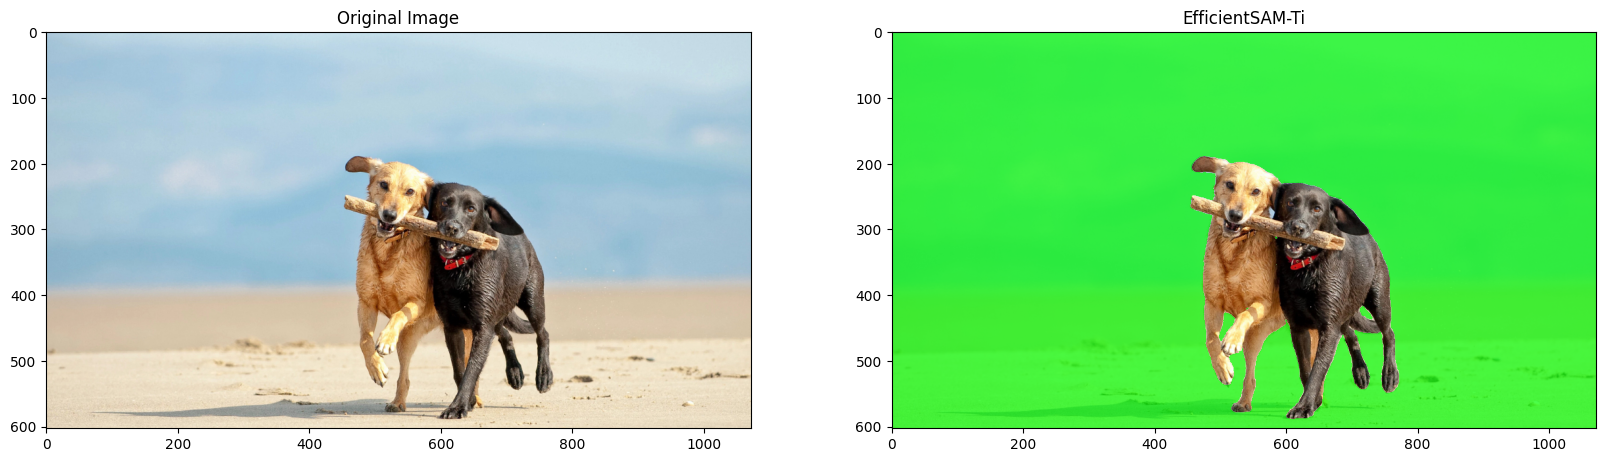

✅ 완료!


In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(20, 20))

# 원본 이미지
ax[0].imshow(image)
ax[0].title.set_text("Original Image")

# EfficientSAM-Ti 결과
ax[1].imshow(image)
mask_efficient_sam_vitt = run_ours_box_or_points(image_path, input_point, input_label, efficient_sam_vitt_model)
show_anns_ours(mask_efficient_sam_vitt, ax[1])
ax[1].title.set_text("EfficientSAM-Ti")

plt.savefig("result.png")
plt.show()
print("✅ 완료!")

## Point segmentation

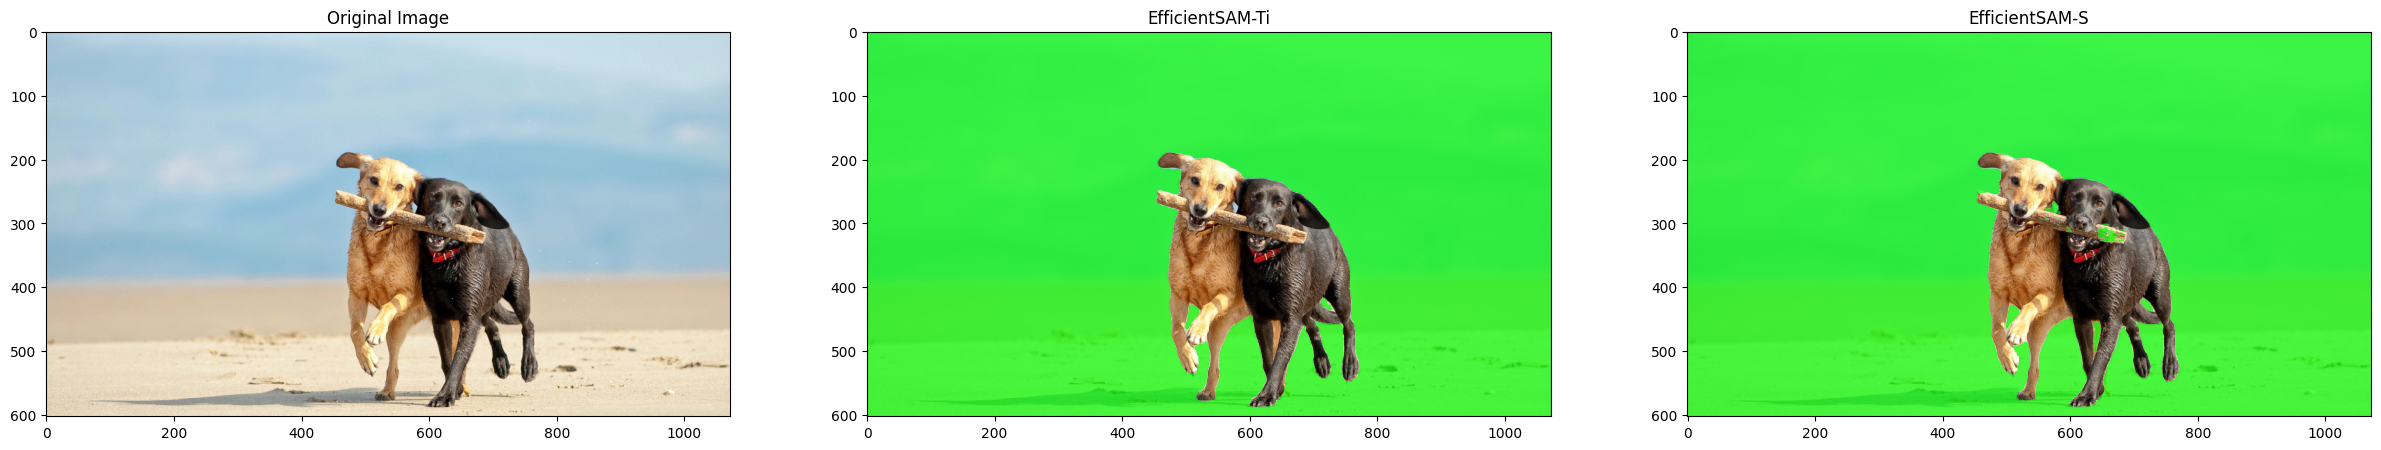

✅ 완료!


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(30, 20))

ax = axes.flatten()

ax[0].imshow(image)
ax[0].title.set_text("Original Image")

ax[1].imshow(image)
mask_efficient_sam_vitt = run_ours_box_or_points(image_path, input_point, input_label, efficient_sam_vitt_model)
show_anns_ours(mask_efficient_sam_vitt, ax[1])
ax[1].title.set_text("EfficientSAM-Ti")

ax[2].imshow(image)
mask_efficient_sam_vits = run_ours_box_or_points(image_path, input_point, input_label, efficient_sam_vits_model)
show_anns_ours(mask_efficient_sam_vits, ax[2])
ax[2].title.set_text("EfficientSAM-S")

plt.savefig("result.png")
plt.show()
print("✅ 완료!")